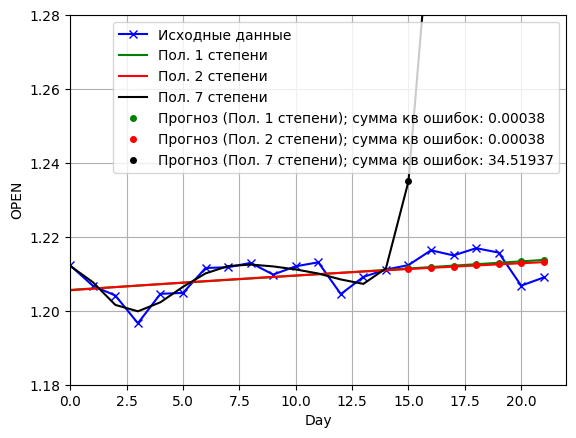

<class 'pandas.DataFrame'>
Index: 22 entries, 0 to 24
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   <TICKER>  22 non-null     str    
 1   <PER>     22 non-null     str    
 2   <DATE>    22 non-null     int64  
 3   <TIME>    22 non-null     int64  
 4   <OPEN>    22 non-null     float64
 5   <HIGH>    22 non-null     float64
 6   <LOW>     22 non-null     float64
 7   <CLOSE>   22 non-null     float64
dtypes: float64(4), int64(2), str(2)
memory usage: 1.5 KB
None


In [2]:
import pandas
from numpy.polynomial import Polynomial
import matplotlib.pyplot as plt
import numpy as np

df = pandas.read_csv('Task_data_EURUSD.csv',sep=";")
df['<OPEN>'] = pandas.to_numeric(df['<OPEN>'],errors='coerce')

df_clean = df.dropna()
df_clean['<OPEN>'] = df_clean['<OPEN>'].astype('float64')

y_all = df_clean['<OPEN>'].values
x_all = np.arange(len(y_all))

train_df = df_clean.head(15)
y_train = train_df['<OPEN>'].values
x_train = np.arange(len(y_train))

x_forecast = np.arange(len(x_train), len(y_all))

poly1 = Polynomial.fit(x_train, y_train, deg=1)
poly2 = Polynomial.fit(x_train, y_train, deg=2)
poly7 = Polynomial.fit(x_train, y_train, deg=7)

y_prog1_f = poly1(x_forecast)
y_prog2_f = poly2(x_forecast)
y_prog7_f = poly7(x_forecast)


y_prog1 = poly1(x_all)
y_prog2 = poly2(x_all)
y_prog7 = poly7(x_all)

def calc_sumK(actual, predict):
    return np.sum((actual - predict)**2)

err_train1 = calc_sumK(y_train, poly1(x_train))
err_train2 = calc_sumK(y_train, poly2(x_train))
err_train7 = calc_sumK(y_train, poly7(x_train))

y_actual_f = y_all[len(x_train):]
err_f1 = calc_sumK(y_actual_f, y_prog1_f)
err_f2 = calc_sumK(y_actual_f, y_prog2_f)
err_f7 = calc_sumK(y_actual_f, y_prog7_f)

err_total1 = err_train1 + err_f1
err_total2 = err_train2 + err_f2
err_total7 = err_train7 + err_f7


plt.figure(1)

plt.plot(x_all, y_all, 'x-', color="blue", label='Исходные данные')
plt.plot(x_all, y_prog1, color='green', label='Пол. 1 степени')
plt.plot(x_all, y_prog2, color='red', label='Пол. 2 степени')
plt.plot(x_all, y_prog7, color='black', label='Пол. 7 степени')

plt.plot(x_forecast, y_prog1_f, 'og', linewidth=2, 
         label=f'Прогноз (Пол. 1 степени); сумма кв ошибок: {err_total1:.5f}', markersize=4)
plt.plot(x_forecast, y_prog2_f, 'or', linewidth=2, 
         label=f'Прогноз (Пол. 2 степени); сумма кв ошибок: {err_total2:.5f}', markersize=4)
plt.plot(x_forecast, y_prog7_f, 'ok', linewidth=2, 
         label=f'Прогноз (Пол. 7 степени); сумма кв ошибок: {err_total7:.5f}', markersize=4)


plt.legend()
plt.ylabel('OPEN')
plt.xlabel('Day')
plt.grid()
plt.xlim(0, 22)
plt.ylim(1.18, 1.28)
plt.show()

print(df_clean.info())